# Day 2 – Technical Indicator Dashboard

## Objective
This project builds a technical indicator dashboard using moving averages, RSI, and MACD to analyze trend and momentum in EURUSD.

## Dataset
Historical EURUSD daily data prepared in Day 1.

## Tools
Python, pandas, numpy, matplotlib

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
#Create output folders for Day 2
os.makedirs("outputs/charts", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

In [3]:
#Load dataset from Day 1
file_path = r"C:\Users\THIS PC\Desktop\quant-finance-portfolio\day-01-market-data-analysis\data\eurusd_daily_raw.csv"
df = pd.read_csv(file_path, index_col=0)
df.head()

,open,high,low,close,simple_return,log_return,cum_return,equity_curve,rolling_peak,drawdown
2007-01-17,1.2917,1.2950,1.2898,1.2938,NaN,NaN,NaN,NaN,NaN,NaN
2007-01-18,1.2938,1.2976,1.2896,1.2963,0.001932,0.001930,0.001932,1.001932,1.001932,0.000000
2007-01-19,1.2963,1.3001,1.2914,1.2961,-0.000154,-0.000154,0.001778,1.001778,1.001932,-0.000154
2007-01-22,1.2959,1.2977,1.2923,1.2949,-0.000926,-0.000926,0.000850,1.000850,1.001932,-0.001080
2007-01-23,1.2949,1.3044,1.2929,1.3026,0.005946,0.005929,0.006802,1.006802,1.006802,0.000000


In [4]:
#Preparing the Dataframe
df.index = pd.to_datetime(df.index)
df = df.sort_index()
df.head()

,open,high,low,close,simple_return,log_return,cum_return,equity_curve,rolling_peak,drawdown
2007-01-17,1.2917,1.2950,1.2898,1.2938,NaN,NaN,NaN,NaN,NaN,NaN
2007-01-18,1.2938,1.2976,1.2896,1.2963,0.001932,0.001930,0.001932,1.001932,1.001932,0.000000
2007-01-19,1.2963,1.3001,1.2914,1.2961,-0.000154,-0.000154,0.001778,1.001778,1.001932,-0.000154
2007-01-22,1.2959,1.2977,1.2923,1.2949,-0.000926,-0.000926,0.000850,1.000850,1.001932,-0.001080
2007-01-23,1.2949,1.3044,1.2929,1.3026,0.005946,0.005929,0.006802,1.006802,1.006802,0.000000


In [5]:
#Check Column
df.columns

Index(['open', 'high', 'low', 'close', 'simple_return', 'log_return',
       'cum_return', 'equity_curve', 'rolling_peak', 'drawdown'],
      dtype='object')

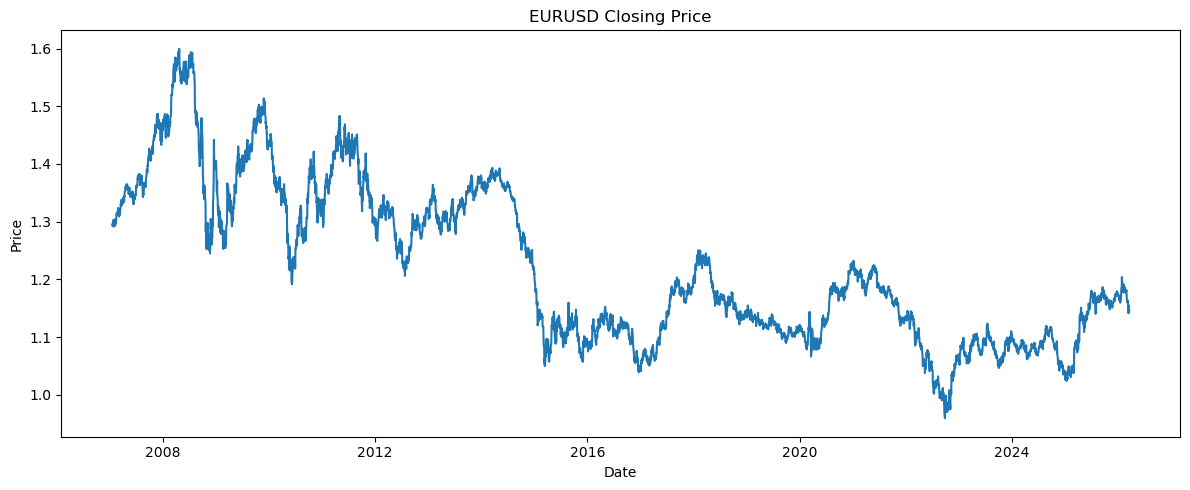

In [6]:
#Plot the Closing Price
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["close"])
plt.title("EURUSD Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig("outputs/charts/day02_close_price.png")
plt.show()

In [7]:
#Compute Moving Average
df["SMA_20"] = df["close"].rolling(window=20).mean()
df["SMA_50"] = df["close"].rolling(window=50).mean()

df[["close", "SMA_20", "SMA_50"]].tail()

,close,SMA_20,SMA_50
2026-03-12,1.1510,1.171790,1.174950
2026-03-13,1.1416,1.169535,1.174344
2026-03-16,1.1503,1.167800,1.173910
2026-03-17,1.1538,1.166225,1.173612
2026-03-18,1.1450,1.164565,1.173166


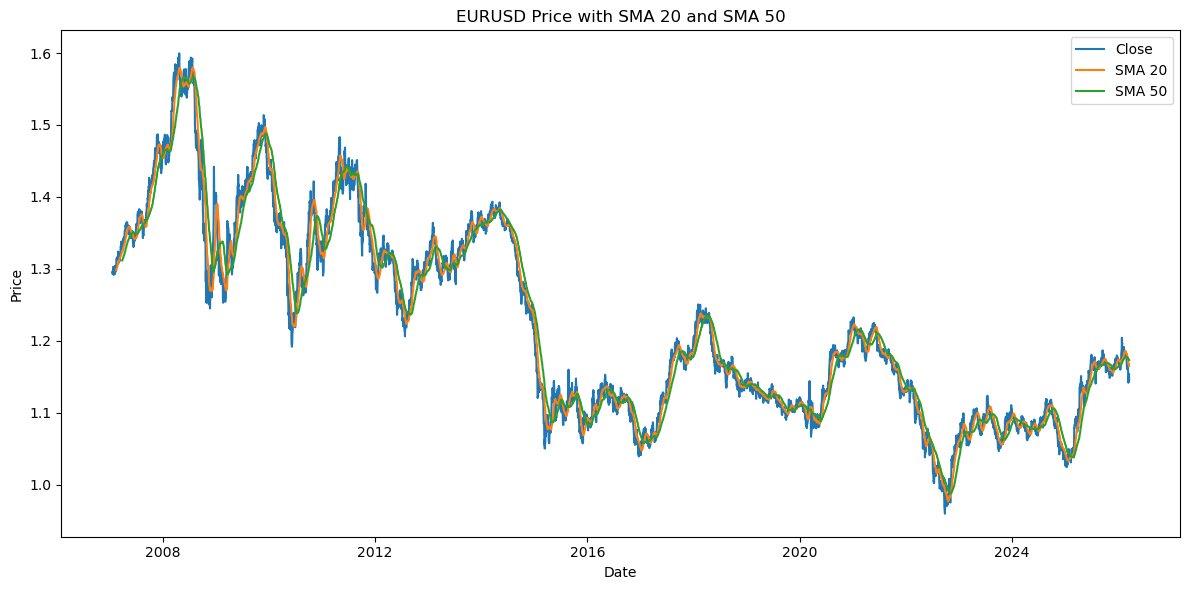

In [8]:
#Plot Price with Moving Average
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["close"], label="Close")
plt.plot(df.index, df["SMA_20"], label="SMA 20")
plt.plot(df.index, df["SMA_50"], label="SMA 50")
plt.title("EURUSD Price with SMA 20 and SMA 50")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/charts/day02_price_with_sma.png")
plt.show()

In [9]:
#Compute RSI
delta = df["close"].diff()

gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss
df["RSI_14"] = 100 - (100 / (1 + rs))

df[["close", "RSI_14"]].tail()

,close,RSI_14
2026-03-12,1.1510,22.107438
2026-03-13,1.1416,17.944251
2026-03-16,1.1503,29.320988
2026-03-17,1.1538,28.992248
2026-03-18,1.1450,25.936200


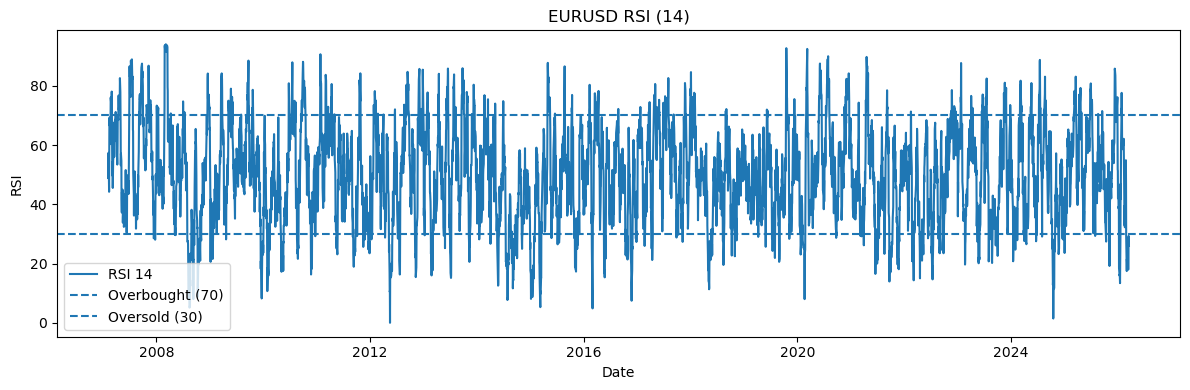

In [11]:
#Plot RSI
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["RSI_14"], label="RSI 14")
plt.axhline(70, linestyle="--", label="Overbought (70)")
plt.axhline(30, linestyle="--", label="Oversold (30)")
plt.title("EURUSD RSI (14)")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/charts/day02_rsi.png")
plt.show()

In [13]:
#Add MACD to the DF
df["EMA_12"] = df["close"].ewm(span=12, adjust=False).mean()
df["EMA_26"] = df["close"].ewm(span=26, adjust=False).mean()

df["MACD"] = df["EMA_12"] - df["EMA_26"]
df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()
df["MACD_Hist"] = df["MACD"] - df["MACD_Signal"]

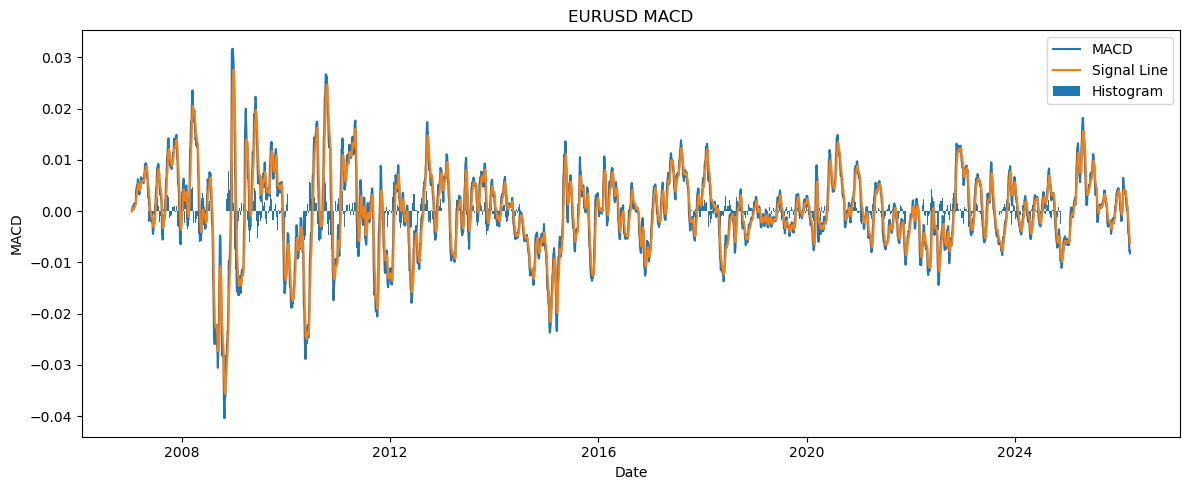

In [14]:
#Plot MACD
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["MACD"], label="MACD")
plt.plot(df.index, df["MACD_Signal"], label="Signal Line")
plt.bar(df.index, df["MACD_Hist"], label="Histogram")
plt.title("EURUSD MACD")
plt.xlabel("Date")
plt.ylabel("MACD")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/charts/day02_macd.png")
plt.show()

In [15]:
#Creating Moving Average Signal
df["MA_Signal"] = np.where(df["SMA_20"] > df["SMA_50"], 1, 0)
df["MA_Crossover"] = df["MA_Signal"].diff()

df[["close", "SMA_20", "SMA_50", "MA_Signal", "MA_Crossover"]].tail(10)

,close,SMA_20,SMA_50,MA_Signal,MA_Crossover
2026-03-05,1.1607,1.178900,1.176628,1,0.0
2026-03-06,1.1618,1.177910,1.176322,1,0.0
2026-03-09,1.1636,1.176525,1.176050,1,0.0
2026-03-10,1.1610,1.175105,1.175778,0,-1.0
2026-03-11,1.1566,1.173585,1.175420,0,0.0
2026-03-12,1.1510,1.171790,1.174950,0,0.0
2026-03-13,1.1416,1.169535,1.174344,0,0.0
2026-03-16,1.1503,1.167800,1.173910,0,0.0
2026-03-17,1.1538,1.166225,1.173612,0,0.0
2026-03-18,1.1450,1.164565,1.173166,0,0.0


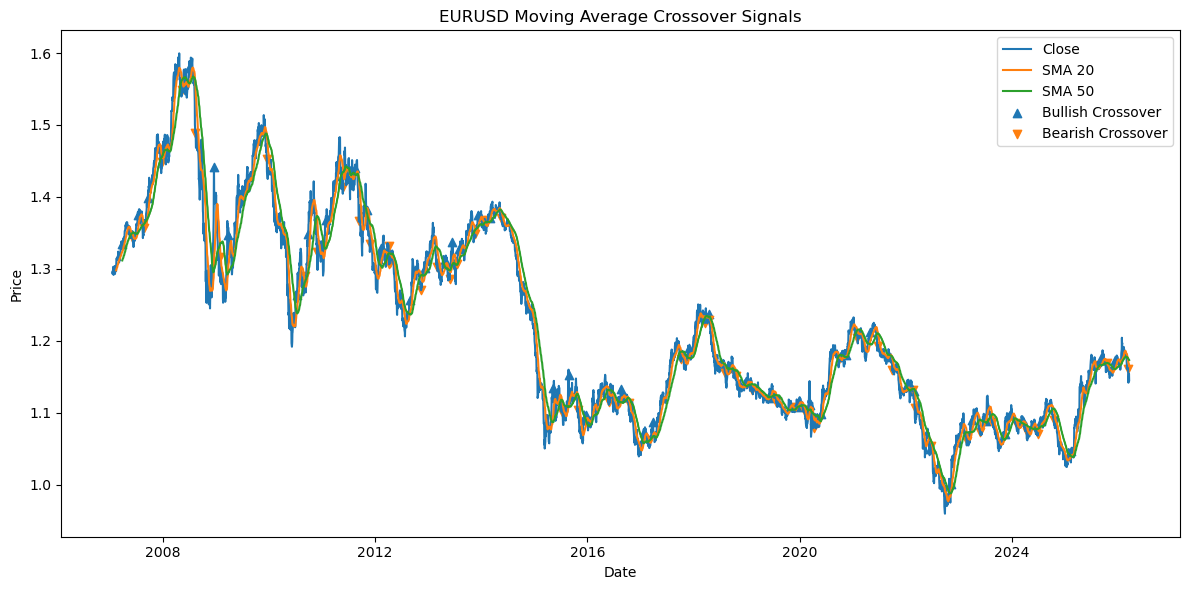

In [16]:
#Plot Cross-Over
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["close"], label="Close")
plt.plot(df.index, df["SMA_20"], label="SMA 20")
plt.plot(df.index, df["SMA_50"], label="SMA 50")

buy_signals = df[df["MA_Crossover"] == 1]
sell_signals = df[df["MA_Crossover"] == -1]

plt.scatter(buy_signals.index, buy_signals["close"], marker="^", label="Bullish Crossover")
plt.scatter(sell_signals.index, sell_signals["close"], marker="v", label="Bearish Crossover")

plt.title("EURUSD Moving Average Crossover Signals")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/charts/day02_ma_crossover_signals.png")
plt.show()

In [17]:
#Creating the summary table
latest = df.iloc[-1]

summary_table = pd.DataFrame({
    "Metric": [
        "Latest Close",
        "Latest SMA 20",
        "Latest SMA 50",
        "Latest RSI 14",
        "Latest MACD",
        "Latest MACD Signal",
        "Current MA Signal"
    ],
    "Value": [
        latest["close"],
        latest["SMA_20"],
        latest["SMA_50"],
        latest["RSI_14"],
        latest["MACD"],
        latest["MACD_Signal"],
        latest["MA_Signal"]
    ]
})

summary_table

,Metric,Value
0,Latest Close,1.145000
1,Latest SMA 20,1.164565
2,Latest SMA 50,1.173166
3,Latest RSI 14,25.936200
4,Latest MACD,-0.008201
5,Latest MACD Signal,-0.006287
6,Current MA Signal,0.000000


In [18]:
#Save the file
summary_table.to_csv("outputs/tables/day02_summary_table.csv", index=False)

df.to_csv("outputs/tables/day02_technical_indicators.csv")

## Analyst Interpretation

The technical dashboard provides a structured view of EURUSD through trend and momentum indicators. The 20-day and 50-day moving averages help identify the prevailing price direction, while crossover points suggest possible changes in short- to medium-term trend.

The RSI adds a momentum-extreme perspective by highlighting conditions where the market may be overbought or oversold. However, in strong trends, RSI can remain elevated or depressed for long periods, so it should be interpreted with caution.

The MACD complements this by capturing changes in momentum through the interaction of short- and long-term exponential moving averages. Crossovers between the MACD and signal line may provide early clues about trend acceleration or weakening momentum.

Taken together, these indicators form a useful dashboard for market monitoring and signal exploration. They do not constitute a complete strategy on their own, but they provide a disciplined basis for developing and testing rule-based trading systems.

## Conclusion

This project extends the Day 1 market analysis by introducing technical indicators commonly used in trading decision-making. The resulting dashboard provides a more actionable framework for studying trend and momentum and sets the stage for the next step: converting technical signals into explicit trading rules and backtesting them.